# Linear Regression: Cost of a security incident

## Exercise:

The exercise involves developing a model to estimate the economic cost of a cybersecurity incident based on a key variable: the number of affected devices. To achieve this, a randomly generated dataset is used, simulating different incident scenarios by varying both the number of compromised systems and the associated cost. The goal is to identify the relationship between these variables and build a predictive model that can approximate the financial impact of future incidents according to their scale.

## 0. Imports

In [7]:
# Installation of external libraries
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn

## 1. Dataset generation

In [8]:
import numpy as np

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.rand(100,1)

print("The length of the dataset is: ", len(X))

The length of the dataset is:  100


## 2. Visualization of dataset

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

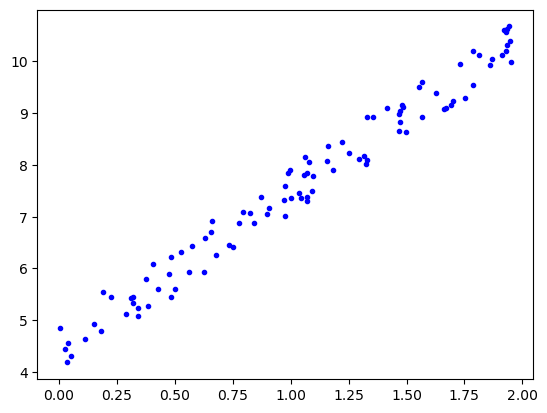

In [10]:
plt.plot(X, y, "b.")
plt.show()

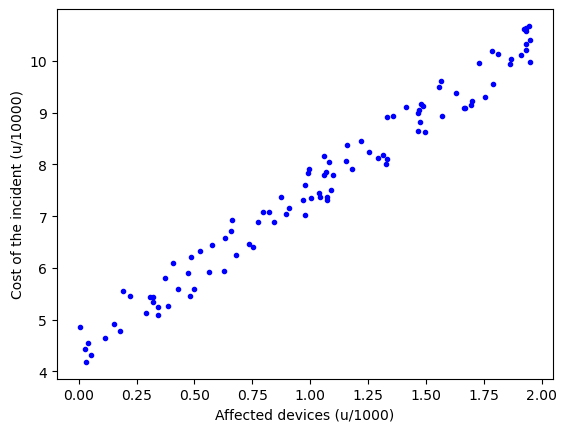

In [11]:
plt.plot(X, y, "b.")
plt.xlabel("Affected devices (u/1000)")
plt.ylabel("Cost of the incident (u/10000)")
plt.show()

## 3. Dataset modification

In [13]:
import pandas as pd

In [15]:
data = {'n_affected_devices': X.flatten(), 'cost': y.flatten()}
df = pd.DataFrame(data)
df.head(10)

,n_affected_devices,cost
0,1.932806,10.625360
1,0.190637,5.552601
2,0.660182,6.925786
3,1.090204,7.503427
4,1.315798,8.179302
5,1.070574,7.376116
6,1.098238,7.789152
7,0.473655,5.895422
8,0.180326,4.790097
9,0.679288,6.254636


In [16]:
# Scaling the number of affected devices
df['n_affected_devices'] = df['n_affected_devices'] * 1000
df['n_affected_devices'] = df['n_affected_devices'].astype('int')

# Scaling the cost
df['cost'] = df['cost'] * 10000
df['cost'] = df['cost'].astype('int')
df.head(10)

,n_affected_devices,cost
0,1932,106253
1,190,55526
2,660,69257
3,1090,75034
4,1315,81793
5,1070,73761
6,1098,77891
7,473,58954
8,180,47900
9,679,62546


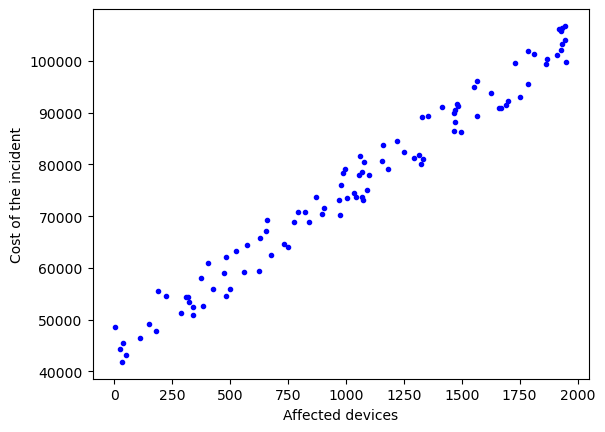

In [20]:
# Dataset visualization
plt.plot(df['n_affected_devices'], df['cost'], "b.")
plt.xlabel('Affected devices')
plt.ylabel('Cost of the incident')
plt.show()

## 4. Model construction

In [21]:
from sklearn.linear_model import LinearRegression

In [23]:
# Model construction and hypothesis function
lin_reg = LinearRegression()
lin_reg.fit(df['n_affected_devices'].values.reshape(-1,1), df['cost'].values)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
# theta 0 parameter
lin_reg.intercept_

np.float64(44386.3257297893)

In [26]:
# theta 1 parameter
lin_reg.coef_

array([30.37050618])

In [33]:
# Prediction for the minimum and maximum value of the training dataset
X_min_max = np.array([
    [df['n_affected_devices'].min()],
    [df['n_affected_devices'].max()]
])

y_train_pred = lin_reg.predict(X_min_max)

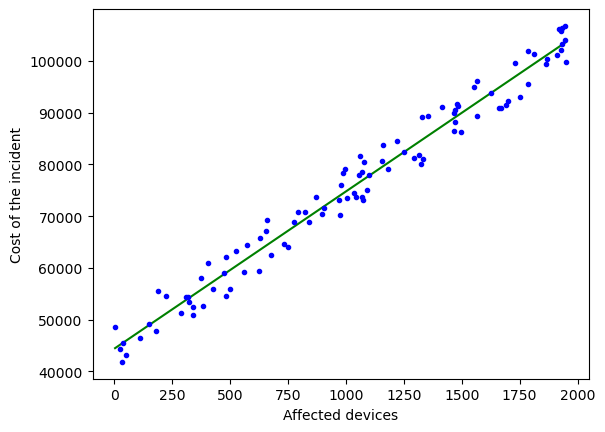

In [36]:
# hypothesis function visualization
plt.plot(X_min_max, y_train_pred, "g-")
plt.plot(df['n_affected_devices'], df['cost'], "b.")
plt.xlabel('Affected devices')
plt.ylabel('Cost of the incident')
plt.show()

## 5. Prediction of new examples

In [47]:
x_new = np.array([[1300], [100], [500]]) # Affected devices

# Cost prediction
cost = lin_reg.predict(x_new)

print("Accident prediction:", int(cost[0]), int(cost[1]), int(cost[2]), "€")


Accident prediction: 83867 47423 59571 €


Text(0, 0.5, 'Cost of the incident')

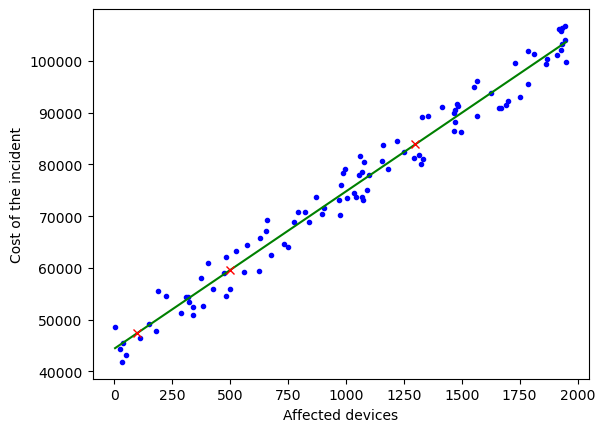

In [48]:
plt.plot(df['n_affected_devices'], df['cost'], "b.")
plt.plot(X_min_max, y_train_pred, "g-")


plt.plot(x_new.flatten(), cost.flatten(), "rx")

plt.xlabel("Affected devices")
plt.ylabel("Cost of the incident")